<a href="https://colab.research.google.com/github/nmartini15/UNCC-Machine-Learning/blob/main/Noah_Martini_801294034_Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Linear Regression with Gradient Descent

**Name:** Noah Martini  
**Student ID:** 801294034  

In [184]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# importing libraries

In [185]:
# Read the provided dataset (D3.csv)
df = pd.read_csv("D3.csv")

# Display the first five rows
print(df.head())

         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375


In [186]:
# Separate features and labels
X1 = df.values[:, 0]  # get input values from first column. X1 is first independent variable
X2 = df.values[:, 1]  # get input values from second column. X2 is second independent variable
X3 = df.values[:, 2]  # get input values from third column. X3 is third independent variable
y  = df.values[:, 3]  # get output values from fourth column. y is output
m = len(y)  # Number of training examples



# Display first 5 records and the total number of training examples
print('X1 = ', X1[: 5])
print('X2 = ', X2[: 5])
print('X3 = ', X3[: 5])
print('y = ', y[: 5])
print('m = ', m)


X1 =  [0.         0.04040404 0.08080808 0.12121212 0.16161616]
X2 =  [3.44       0.1349495  0.82989899 1.52484848 2.21979798]
X3 =  [0.44       0.88848485 1.3369697  1.78545454 2.23393939]
y =  [4.38754501 2.6796499  2.96848981 3.25406475 3.53637472]
m =  100


In [187]:
# prints all of the data
print('X1 = ', X1[: 100])
print('X2 = ', X2[: 100])
print('X3 = ', X3[: 100])
print('y = ', y[: 100])

X1 =  [0.         0.04040404 0.08080808 0.12121212 0.16161616 0.2020202
 0.24242424 0.28282828 0.32323232 0.36363636 0.4040404  0.44444444
 0.48484848 0.52525252 0.56565657 0.60606061 0.64646465 0.68686869
 0.72727273 0.76767677 0.80808081 0.84848485 0.88888889 0.92929293
 0.96969697 1.01010101 1.05050505 1.09090909 1.13131313 1.17171717
 1.21212121 1.25252525 1.29292929 1.33333333 1.37373737 1.41414141
 1.45454546 1.49494949 1.53535354 1.57575758 1.61616162 1.65656566
 1.6969697  1.73737374 1.77777778 1.81818182 1.85858586 1.8989899
 1.93939394 1.97979798 2.02020202 2.06060606 2.1010101  2.14141414
 2.18181818 2.22222222 2.26262626 2.3030303  2.34343434 2.38383838
 2.42424242 2.46464646 2.5050505  2.54545455 2.58585859 2.62626263
 2.66666667 2.70707071 2.74747475 2.78787879 2.82828283 2.86868687
 2.90909091 2.94949495 2.98989899 3.03030303 3.07070707 3.11111111
 3.15151515 3.19191919 3.23232323 3.27272727 3.31313131 3.35353535
 3.39393939 3.43434343 3.47474748 3.51515151 3.55555556 3.

In [188]:
from IPython.display import display
display(df)

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375
...,...,...,...,...
95,3.838384,1.460202,3.046061,-4.440595
96,3.878788,2.155152,3.494545,-4.458663
97,3.919192,2.850101,3.943030,-4.479995
98,3.959596,3.545051,0.391515,-3.304593


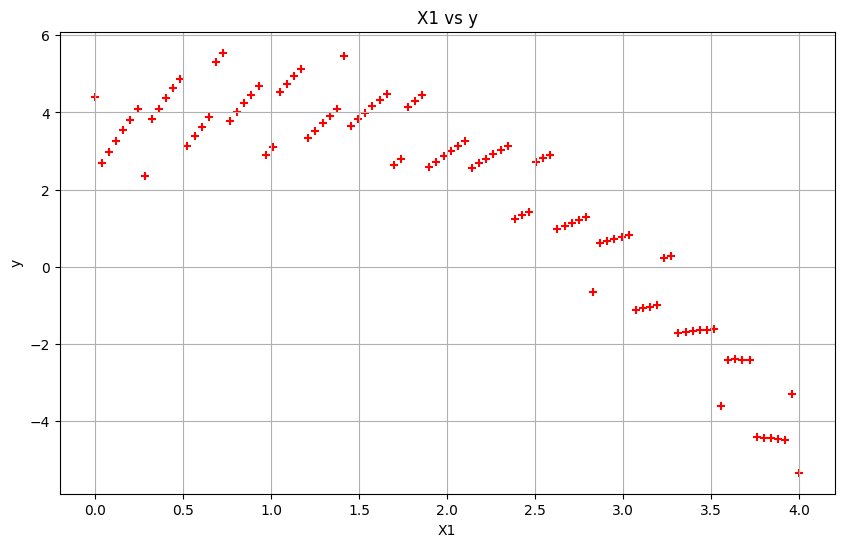

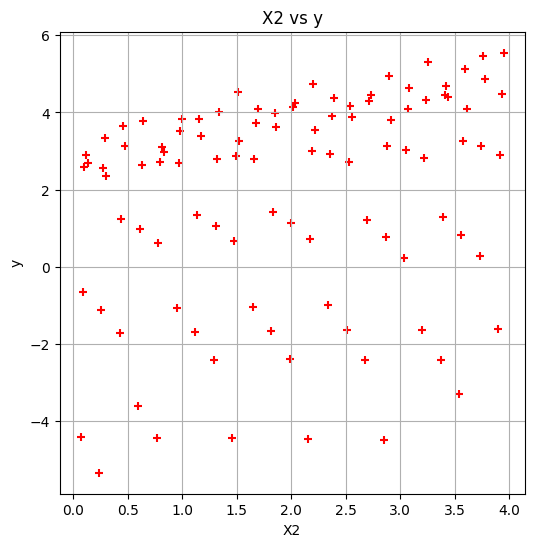

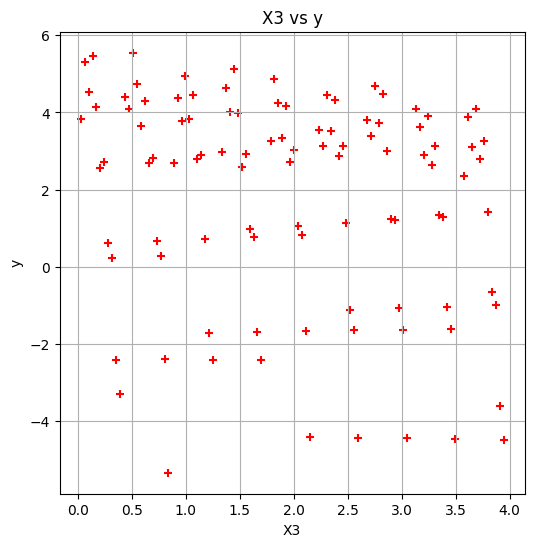

In [189]:
#Problem 1


#plot 1: X1 vs y

plt.scatter(X1, y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X1')
plt.ylabel('y')
plt.title('X1 vs y')

# Show the plot
plt.show()

#plot 2: X2 vs y

plt.scatter(X2, y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X2')
plt.ylabel('y')
plt.title('X2 vs y')

# Show the plot
plt.show()

#plot 3: X3 vs y

plt.scatter(X3, y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X3')
plt.ylabel('y')
plt.title('X3 vs y')

# Show the plot
plt.show()



In [190]:

X_0 = np.ones((m, 1))
X_0[:5]

X_1 = X1.reshape(m, 1)
X_1[:10]

# Lets use hstack() function from numpy to stack X_0 and X_1 horizontally (i.e. column
# This will be our final X matrix (feature matrix)
X1 = np.hstack((X_0, X_1))
X1[:5]


theta = np.zeros(2)
theta

array([0., 0.])

In [191]:

def compute_cost(X, y, theta):
    """
    Compute cost for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represent the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)

    Returns:
    J : Scalar value, the cost
    """
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)
    return J

In [192]:
cost = compute_cost(X1, y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost)

The cost for given values of theta_0 and theta_1 = 5.524438459196242


In [193]:
def gradient_descent(X, y, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represents the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)

    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m = len(y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = np.subtract(predictions, y)
        sum_delta = (alpha / m) * X.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

In [194]:

theta = [0., 0.]
iterations = 1500
alpha = 0.1


theta, cost_history = gradient_descent(X1, y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)


Final value of theta = [ 5.92794892 -2.03833663]
cost_history = [5.16999006 4.96338989 4.7855721  ... 0.98499308 0.98499308 0.98499308]


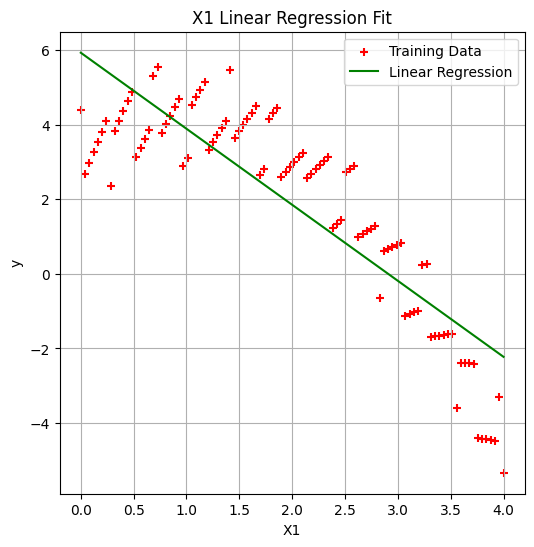

In [195]:
# X1 linear regression data plot

# Scatter plot for the training data
plt.scatter(X1[:, 1], y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X1[:, 1], X1.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X1')
plt.ylabel('y')
plt.title('X1 Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()


The cost for given values of theta_0 and theta_1 = 5.524438459196242
Final value of theta = [0.73606043 0.55760761]
cost_history = [3.90731819 3.66528504 3.62832072 ... 3.59936602 3.59936602 3.59936602]


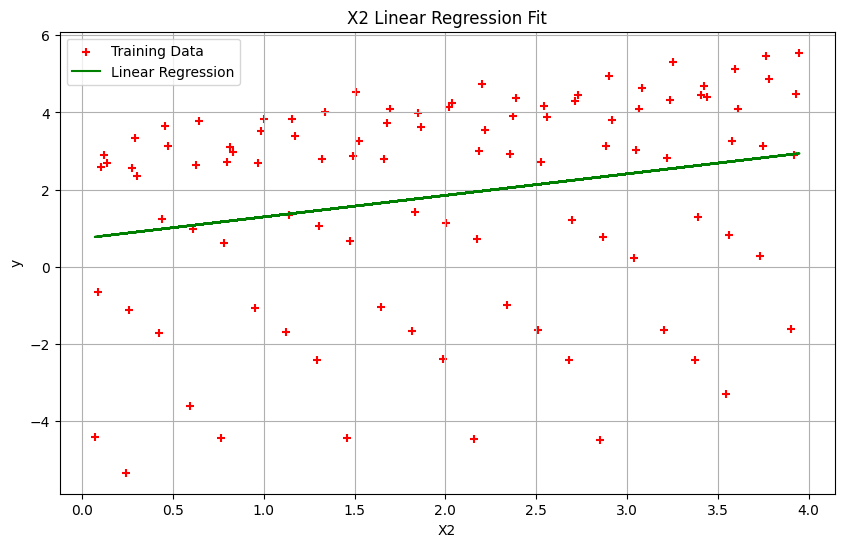

In [196]:
# X2 linear regression data plot

X_0 = np.ones((m, 1))
X_0[:5]

X_2 = X2.reshape(m, 1)
X_2[:10]

# Lets use hstack() function from numpy to stack X_0 and X_2 horizontally

X2 = np.hstack((X_0, X_2))
X2[:5]


theta = np.zeros(2)
theta

cost2 = compute_cost(X2, y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost2)


theta = [0., 0.]
iterations = 1500
alpha = 0.1


theta, cost_history = gradient_descent(X2, y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)



# Scatter plot for the training data
plt.scatter(X2[:, 1], y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X2[:, 1], X2.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X2')
plt.ylabel('y')
plt.title('X2 Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

The cost for given values of theta_0 and theta_1 = 5.524438459196242
Final value of theta = [ 2.8714221  -0.52048288]
cost_history = [4.66843939 4.49602325 4.43685075 ... 3.62945112 3.62945112 3.62945112]


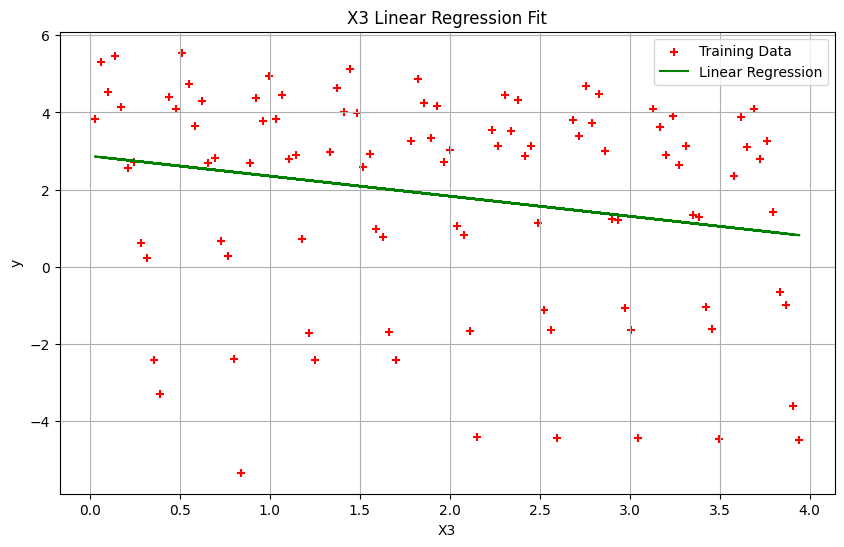

In [197]:
# X3 linear regression data plot

X_0 = np.ones((m, 1))
X_0[:5]

X_3 = X3.reshape(m, 1)
X_3[:10]

# Lets use hstack() function from numpy to stack X_0 and X_3 horizontally
X3 = np.hstack((X_0, X_3))
X3[:5]


theta = np.zeros(2)
theta

cost3 = compute_cost(X3, y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost3)


theta = [0., 0.]
iterations = 1500
alpha = 0.1


theta, cost_history = gradient_descent(X3, y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)


# Scatter plot for the training data
plt.scatter(X3[:, 1], y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X3[:, 1], X3.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X3')
plt.ylabel('y')
plt.title('X3 Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

alpha = 0.01, theta = [ 5.71850653 -1.9568206 ], final cost = 0.9905894438682062
alpha = 0.05, theta = [ 5.9279486  -2.03833651], final cost = 0.9849930825406077
alpha = 0.1, theta = [ 5.92794892 -2.03833663], final cost = 0.9849930825405946


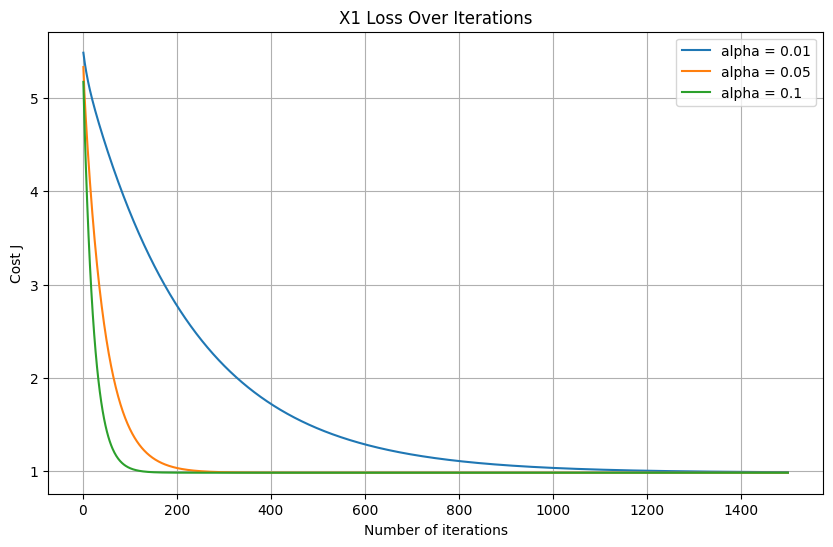

In [198]:

# X1 learning rate comparison

learning_rates = [0.01, 0.05, 0.1]
iterations = 1500

for alpha in learning_rates:
    theta_initial = np.zeros(2)

    theta_result, history = gradient_descent(
        X1,
        y,
        theta_initial,
        alpha,
        iterations
    )

    plt.plot(
        range(1, iterations + 1),
        history,
        label=f"alpha = {alpha}"
    )

    print(
        f"alpha = {alpha}, "
        f"theta = {theta_result}, "
        f"final cost = {history[-1]}"
    )

plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.title("X1 Loss Over Iterations")
plt.grid(True)
plt.legend()
plt.show()

alpha = 0.01, theta = [0.71988473 0.56390334], final cost = 3.5993993982305357
alpha = 0.05, theta = [0.73606041 0.55760762], final cost = 3.5993660181680425
alpha = 0.1, theta = [0.73606043 0.55760761], final cost = 3.599366018168041


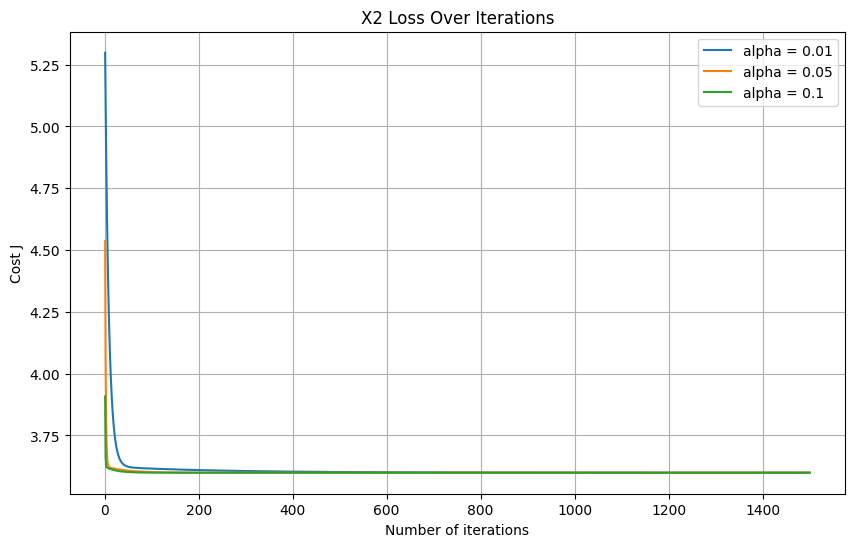

In [199]:
# X2 learning rate comparison

learning_rates = [0.01, 0.05, 0.1]
iterations = 1500

for alpha in learning_rates:
    theta_initial = np.zeros(2)

    theta_result, history = gradient_descent(
        X2,
        y,
        theta_initial,
        alpha,
        iterations
    )

    plt.plot(
        range(1, iterations + 1),
        history,
        label=f"alpha = {alpha}"
    )

    print(
        f"alpha = {alpha}, "
        f"theta = {theta_result}, "
        f"final cost = {history[-1]}"
    )

plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.title("X2 Loss Over Iterations")
plt.grid(True)
plt.legend()
plt.show()

alpha = 0.01, theta = [ 2.78048129 -0.48451631], final cost = 3.6305262475389664
alpha = 0.05, theta = [ 2.87142199 -0.52048284], final cost = 3.629451124607917
alpha = 0.1, theta = [ 2.8714221  -0.52048288], final cost = 3.6294511246079155


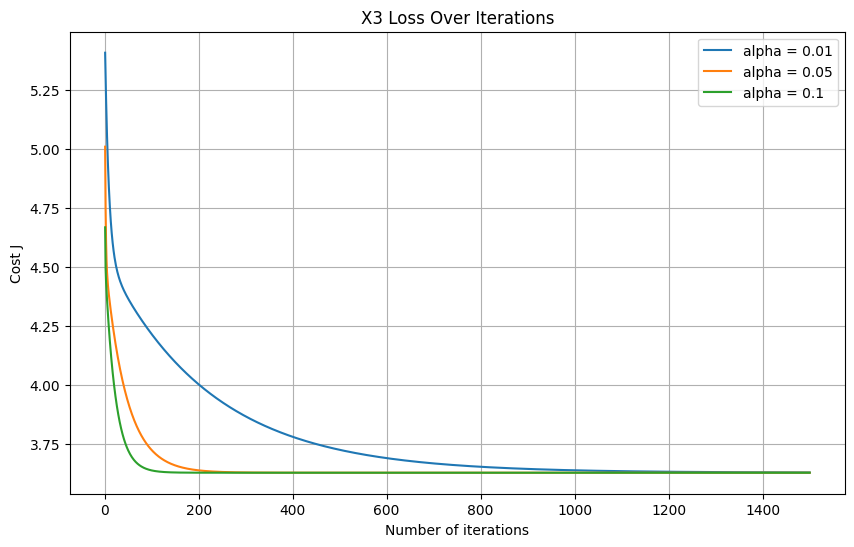

In [200]:
# X3 learning rate comparison

learning_rates = [0.01, 0.05, 0.1]
iterations = 1500

for alpha in learning_rates:
    theta_initial = np.zeros(2)

    theta_result, history = gradient_descent(
        X3,
        y,
        theta_initial,
        alpha,
        iterations
    )

    plt.plot(
        range(1, iterations + 1),
        history,
        label=f"alpha = {alpha}"
    )

    print(
        f"alpha = {alpha}, "
        f"theta = {theta_result}, "
        f"final cost = {history[-1]}"
    )

plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.title("X3 Loss Over Iterations")
plt.grid(True)
plt.legend()
plt.show()

Problem 1 Conclusions

The final models were approximately:

X1: y = 5.927949 - 2.038337X1 final
cost = 0.9849930825405946

X2: y = 0.736060 + 0.557608X2
final cost = 3.599366018168041

X3: y = 2.871422 - 0.520483X3
final cost = 3.6294511246079155

(with alpha = .1)

X1 produced the lowest cost of approximately 0.984993. Therefore, X1 was the
best variable for predicting Y.

The learning rate of 0.10 converged fastest, followed by 0.05. The learning
rate of 0.01 required more iterations to approach the same minimum. None of
the tested learning rates diverged.

In [201]:
# Problem 2

# Retrieve the original explanatory variables from the dataset
X1_multi = df.values[:, 0]
X2_multi = df.values[:, 1]
X3_multi = df.values[:, 2]

# Retrieve the dependent variable
y_multi = df.values[:, 3]

m = len(y_multi)

print("Number of training examples =", m)

Number of training examples = 100


In [202]:
X_0_multi = np.ones((m, 1))

# get inputs and turn them into matrix

X_1_multi = X1_multi.reshape(m, 1)
X_2_multi = X2_multi.reshape(m, 1)
X_3_multi = X3_multi.reshape(m, 1)

X_multi = np.hstack((
    X_0_multi,
    X_1_multi,
    X_2_multi,
    X_3_multi
))

print("First five rows of the combined feature matrix:")
print(X_multi[:5])

print("Shape of feature matrix:", X_multi.shape)

First five rows of the combined feature matrix:
[[1.         0.         3.44       0.44      ]
 [1.         0.04040404 0.1349495  0.88848485]
 [1.         0.08080808 0.82989899 1.3369697 ]
 [1.         0.12121212 1.52484848 1.78545454]
 [1.         0.16161616 2.21979798 2.23393939]]
Shape of feature matrix: (100, 4)


In [203]:
theta_multi = np.zeros(4)

print("Initial theta =", theta_multi)

initial_cost_multi = compute_cost(
    X_multi,
    y_multi,
    theta_multi
)

print("Initial cost =", initial_cost_multi)

learning_rates = [0.01, 0.05, 0.1]
iterations = 1500

Initial theta = [0. 0. 0. 0.]
Initial cost = 5.524438459196242


alpha = 0.01, theta = [ 4.15118728 -1.8394291   0.72473856 -0.09513266], final cost = 0.8105104429083866
alpha = 0.05, theta = [ 5.31128136 -2.0033116   0.5330402  -0.26517886], final cost = 0.7384646851794184
alpha = 0.1, theta = [ 5.31416563 -2.00371905  0.53256359 -0.26560164], final cost = 0.7384642415684215


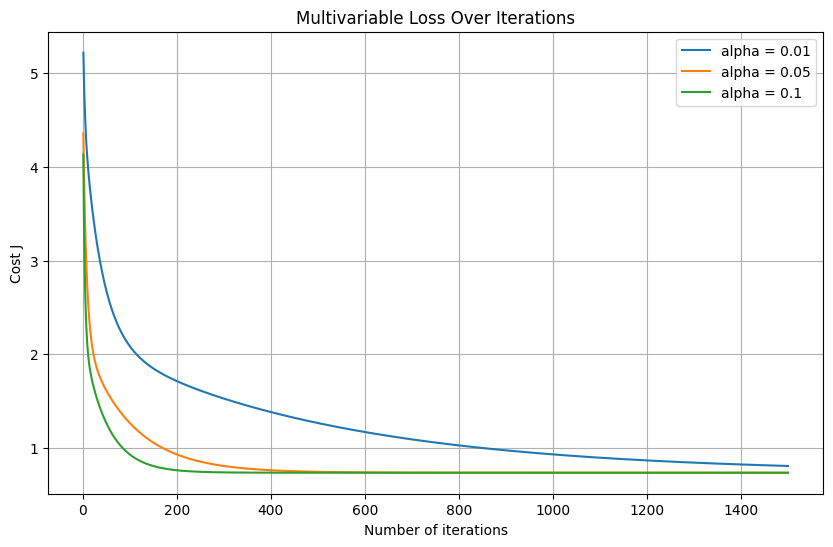

Best learning rate = 0.1
Final theta = [ 5.31416563 -2.00371905  0.53256359 -0.26560164]
Final cost = 0.7384642415684215


In [204]:


for alpha in learning_rates:
    theta_initial = np.zeros(4)

    theta_result, cost_history = gradient_descent(
        X_multi,
        y_multi,
        theta_initial,
        alpha,
        iterations
    )

    print(
        f"alpha = {alpha}, "
        f"theta = {theta_result}, "
        f"final cost = {cost_history[-1]}"
    )

    plt.plot(
        range(1, iterations + 1),
        cost_history,
        label=f"alpha = {alpha}"
    )

plt.grid(True)
plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.title("Multivariable Loss Over Iterations")
plt.legend()
plt.show()

best_alpha = 0.1
iterations = 1500
theta_initial = np.zeros(4)

theta_best, cost_history_best = gradient_descent(
    X_multi,
    y_multi,
    theta_initial,
    best_alpha,
    iterations
)

print("Best learning rate =", best_alpha)
print("Final theta =", theta_best)
print("Final cost =", cost_history_best[-1])

In [205]:
print(
    f"Final model: y = "
    f"{theta_best[0]:.6f} "
    f"+ ({theta_best[1]:.6f})X1 "
    f"+ ({theta_best[2]:.6f})X2 "
    f"+ ({theta_best[3]:.6f})X3"
)

new_values = np.array([
    [1, 1, 1, 1],
    [1, 2, 0, 4],
    [1, 3, 2, 1]
])

predictions = new_values.dot(theta_best)

print("Prediction for (1, 1, 1) =", predictions[0])
print("Prediction for (2, 0, 4) =", predictions[1])
print("Prediction for (3, 2, 1) =", predictions[2])

Final model: y = 5.314166 + (-2.003719)X1 + (0.532564)X2 + (-0.265602)X3
Prediction for (1, 1, 1) = 3.5774085293454623
Prediction for (2, 0, 4) = 0.2443209702176521
Prediction for (3, 2, 1) = 0.10253401973591991


Problem 2 Conclusions

The final multivariable model produced a cost of approximately 0.738464, which
was lower than the cost of any individual-variable model. The learning rate of
0.10 converged fastest without becoming unstable, so it was selected for the
final model.